# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


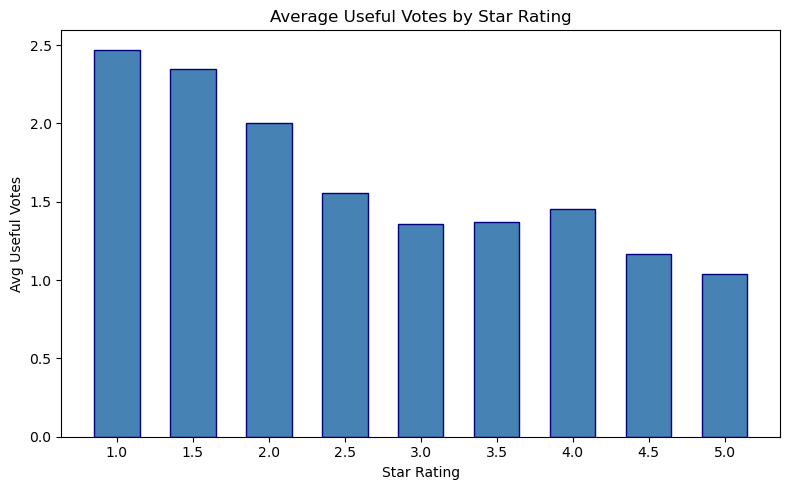

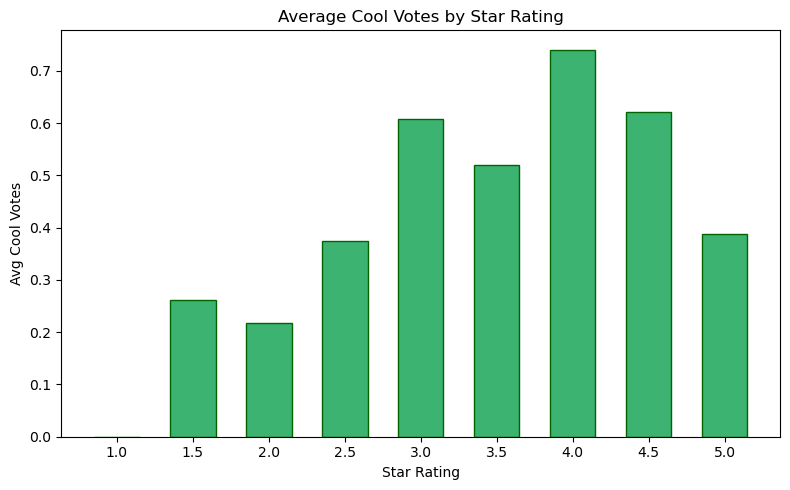

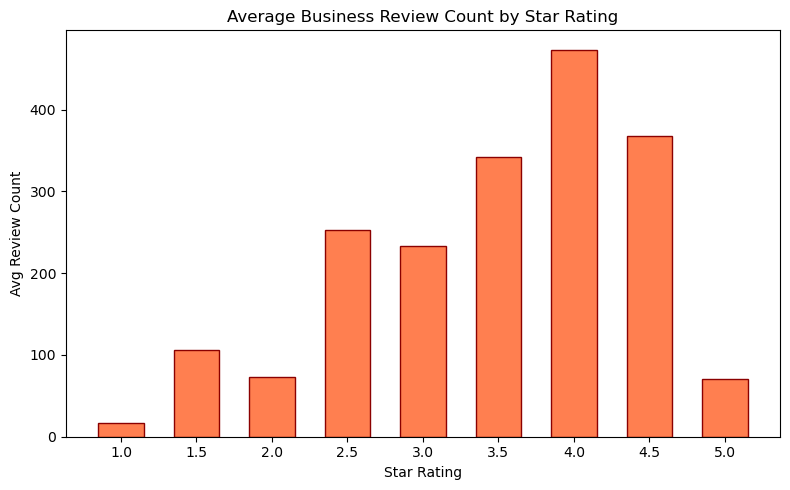

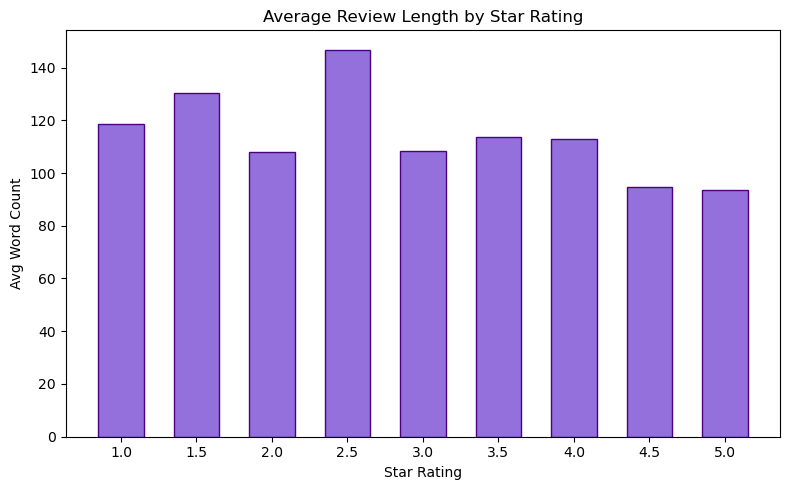

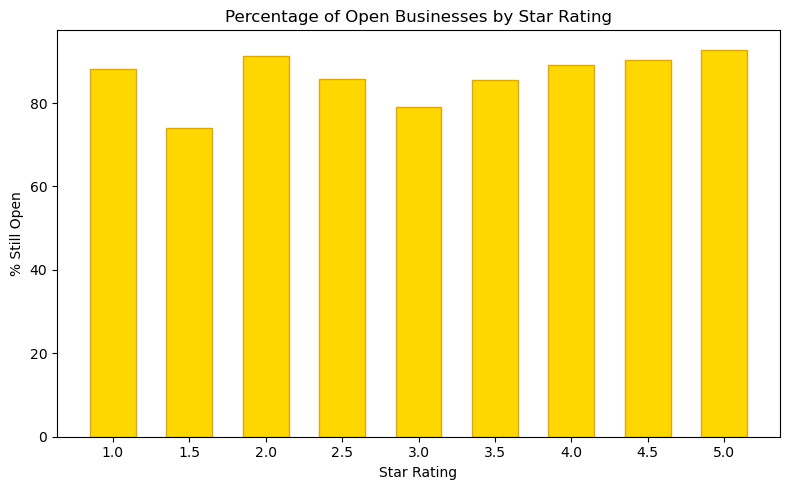

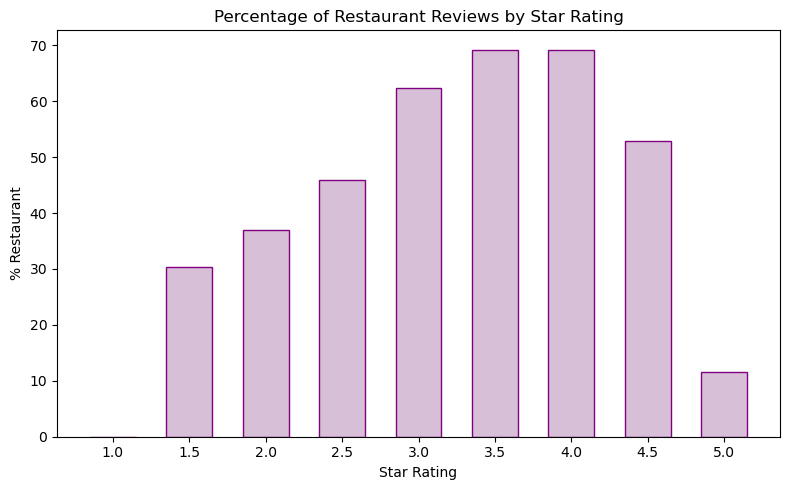

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('yelp_subset.csv')
df.columns = df.columns.str.strip().str.lstrip('\ufeff')

df['review_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['is_restaurant'] = df['categories'].astype(str).str.lower().str.contains('restaurant').astype(int)

star_order = sorted(df['stars'].dropna().unique())

useful_by_stars = df.groupby('stars')['useful'].mean()
plt.figure(figsize=(8, 5))
plt.bar(useful_by_stars.index, useful_by_stars.values, width=0.3, color='steelblue', edgecolor='navy')
plt.title('Average Useful Votes by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Avg Useful Votes')
plt.xticks(star_order)
plt.tight_layout()
plt.show()

cool_by_stars = df.groupby('stars')['cool'].mean()
plt.figure(figsize=(8, 5))
plt.bar(cool_by_stars.index, cool_by_stars.values, width=0.3, color='mediumseagreen', edgecolor='darkgreen')
plt.title('Average Cool Votes by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Avg Cool Votes')
plt.xticks(star_order)
plt.tight_layout()
plt.show()

review_count_by_stars = df.groupby('stars')['review_count'].mean()
plt.figure(figsize=(8, 5))
plt.bar(review_count_by_stars.index, review_count_by_stars.values, width=0.3, color='coral', edgecolor='darkred')
plt.title('Average Business Review Count by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Avg Review Count')
plt.xticks(star_order)
plt.tight_layout()
plt.show()

length_by_stars = df.groupby('stars')['review_length'].mean()
plt.figure(figsize=(8, 5))
plt.bar(length_by_stars.index, length_by_stars.values, width=0.3, color='mediumpurple', edgecolor='indigo')
plt.title('Average Review Length by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Avg Word Count')
plt.xticks(star_order)
plt.tight_layout()
plt.show()

is_open_by_stars = df.groupby('stars')['is_open'].mean() * 100
plt.figure(figsize=(8, 5))
plt.bar(is_open_by_stars.index, is_open_by_stars.values, width=0.3, color='gold', edgecolor='goldenrod')
plt.title('Percentage of Open Businesses by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('% Still Open')
plt.xticks(star_order)
plt.tight_layout()
plt.show()

restaurant_by_stars = df.groupby('stars')['is_restaurant'].mean() * 100
plt.figure(figsize=(8, 5))
plt.bar(restaurant_by_stars.index, restaurant_by_stars.values, width=0.3, color='thistle', edgecolor='purple')
plt.title('Percentage of Restaurant Reviews by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('% Restaurant')
plt.xticks(star_order)
plt.tight_layout()
plt.show()

In [ ]:
# Dataset: 2,000 Yelp reviews with 20 features. Target is stars (1.0–5.0 in 0.5 steps).
# Features used: useful votes, cool votes, review_count, review_length, is_open, is_restaurant.
# Most reviews are positive — 4.0 stars is the most common rating.

# Figure 1 — Useful Votes by Star Rating
# Low-star reviews get more useful votes. Critical reviews are seen as more informative.

# Figure 2 — Cool Votes by Star Rating
# Cool votes peak around 4.0 stars and drop at both extremes.

# Figure 3 — Business Review Count by Star Rating
# Businesses rated 3.5–4.5 stars have the most reviews. Popular businesses attract more feedback.

# Figure 4 — Review Length by Star Rating
# Word count is flat across all ratings. Review length has little relationship with the target.

# Figure 5 — Open Businesses by Star Rating
# Higher-rated businesses are slightly more likely to still be open, but the gap is small.

# Figure 6 — Restaurant Reviews by Star Rating
# Mid-range ratings are mostly restaurants. 1-star and 5-star reviews are less restaurant-heavy.

# Most related: useful votes and review_count.
# Least related: review length.
# Conclusion: critical reviews are valued most by readers, while higher-rated businesses naturally accumulate more reviews over time.
